In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from astroML.classification import GMMBayes
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv('/Users/lorenzaimpicicche/Desktop/astrostatistics_bicocca_2025/solutions/galaxyquasar.csv')

In [16]:
df

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [17]:
df['u-g']=df['u']-df['g']
df['g-r']=df['g']-df['r']
df['r-i']=df['r']-df['i']
df['i-z']=df['i']-df['z']

In [18]:
df

,u,g,r,i,z,class,z1,zerr,u-g,g-r,r-i,i-z
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155,0.43537,-0.04604,0.23344,0.05721
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028,1.76946,0.99829,0.43345,0.35621
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000,1.73268,0.78703,0.33238,0.19199
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009,1.13314,0.78721,0.45042,0.29154
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631,0.17640,0.22251,0.08924,0.30830
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011,1.24913,0.72496,0.41383,0.27918
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014,1.63759,0.84982,0.46396,0.34430
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008,1.31842,0.43505,0.24972,0.20103
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009,1.27429,0.65610,0.40154,0.18600


In [19]:
X=df[['u-g', 'g-r', 'r-i', 'i-z']].values #featrures matrix
X

array([[ 0.43537, -0.04604,  0.23344,  0.05721],
       [ 1.76946,  0.99829,  0.43345,  0.35621],
       [ 1.73268,  0.78703,  0.33238,  0.19199],
       ...,
       [ 1.31842,  0.43505,  0.24972,  0.20103],
       [ 1.27429,  0.6561 ,  0.40154,  0.186  ],
       [ 1.05021,  0.35251,  0.1885 ,  0.09355]])

In [20]:
le = LabelEncoder()
y = le.fit_transform(df['class'])  #GALAXY=0, QSO=1

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y) # stratify=y class balanced

### 1. naive bayes

In [22]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:, 1]

### 2. GMM bayes

In [23]:
gmm = GMMBayes(n_components=3)
gmm.fit(X_train, y_train)
y_pred_gmm = gmm.predict(X_test)
y_prob_gmm = gmm.predict_proba(X_test)[:, 1]

### 3. K Nearest Neighbors

In [24]:
best_score=0
best_k=1
for k in range(1, 20):
    knn=KNeighborsClassifier(n_neighbors=k)
    score=np.mean(cross_val_score(knn, X_train, y_train, cv=5))
    if score>best_score:
        best_score = score
        best_k = k

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]

In [25]:
best_k

10

## Evaluate classifier performance with ROC


Naive Bayes Performance:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98     10717
           1       0.89      0.91      0.90      1783

    accuracy                           0.97     12500
   macro avg       0.94      0.95      0.94     12500
weighted avg       0.97      0.97      0.97     12500


GMM Bayes Performance:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98     10717
           1       0.87      0.94      0.90      1783

    accuracy                           0.97     12500
   macro avg       0.93      0.96      0.94     12500
weighted avg       0.97      0.97      0.97     12500


KNN (k=10) Performance:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     10717
           1       0.96      0.93      0.95      1783

    accuracy                           0.98     12500
   macro avg       0.98      0.96      0.97     12

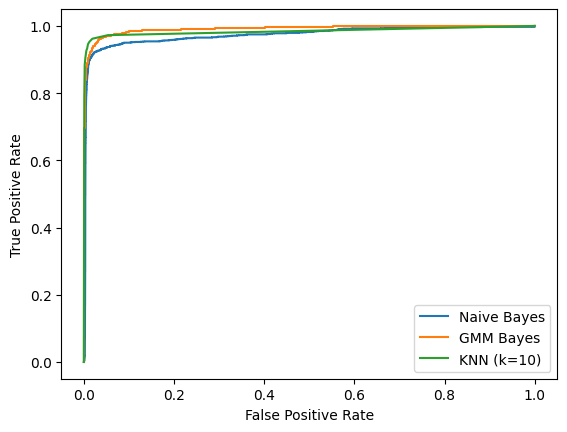

In [26]:
def ev_m(y_test, y_pred, y_prob,name):
    print(f"\n{name} Performance:\n")
    print(classification_report(y_test, y_pred))

    fpr, tpr, _ =roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name}")

auc_nb=ev_m(y_test, y_pred_nb, y_prob_nb, "Naive Bayes")
auc_gmm=ev_m(y_test, y_pred_gmm, y_prob_gmm, "GMM Bayes")
auc_knn=ev_m(y_test, y_pred_knn, y_prob_knn, f"KNN (k=10)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()